# Task I: Quantum Computing Part
**GSoC 2026 | QMLHEP | Quantum Reinforcement Learning for High Energy Physics**

This notebook implements two quantum circuits using **PennyLane**:
1. A 5-qubit circuit with H, CNOT chain, SWAP, and RX gates
2. A 4-qubit + ancilla circuit performing a **Swap Test** between two 2-qubit states

In [2]:

!pip install pennylane matplotlib numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 58.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 50.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 79.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 84.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 105.6 MB/s eta 0:00:00


In [3]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

print(f'PennyLane version: {qml.__version__}')

PennyLane version: 0.44.0


---
## Circuit 1: 5-Qubit Circuit

Steps:
- Apply **Hadamard** to all 5 qubits → superposition
- Apply **CNOT** chain: (0→1), (1→2), (2→3), (3→4) → entanglement
- Apply **SWAP** between qubits 0 and 4
- Apply **RX(π/2)** rotation on qubit 0

In [4]:
# ── Device ──────────────────────────────────────────────────────────────────
dev1 = qml.device('default.qubit', wires=5)

@qml.qnode(dev1)
def circuit1():
    # a) 5 qubits already defined via wires=5

    # b) Hadamard on every qubit
    for i in range(5):
        qml.Hadamard(wires=i)

    # c) CNOT chain: (0,1), (1,2), (2,3), (3,4)
    for ctrl, tgt in [(0,1),(1,2),(2,3),(3,4)]:
        qml.CNOT(wires=[ctrl, tgt])

    # d) SWAP between qubit 0 and qubit 4
    qml.SWAP(wires=[0, 4])

    # e) RX rotation of π/2 on qubit 0
    qml.RX(np.pi / 2, wires=0)

    # f) Return state vector
    return qml.state()

# Run and print state
state1 = circuit1()
print('Output state vector (first 8 amplitudes):')
for i, amp in enumerate(state1[:8]):
    print(f'  |{i:05b}⟩: {amp:.4f}')

Output state vector (first 8 amplitudes):
  |00000⟩: 0.1250-0.1250j
  |00001⟩: 0.1250-0.1250j
  |00010⟩: 0.1250-0.1250j
  |00011⟩: 0.1250-0.1250j
  |00100⟩: 0.1250-0.1250j
  |00101⟩: 0.1250-0.1250j
  |00110⟩: 0.1250-0.1250j
  |00111⟩: 0.1250-0.1250j


/tmp/ipython-input-347/3024203758.py:4: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


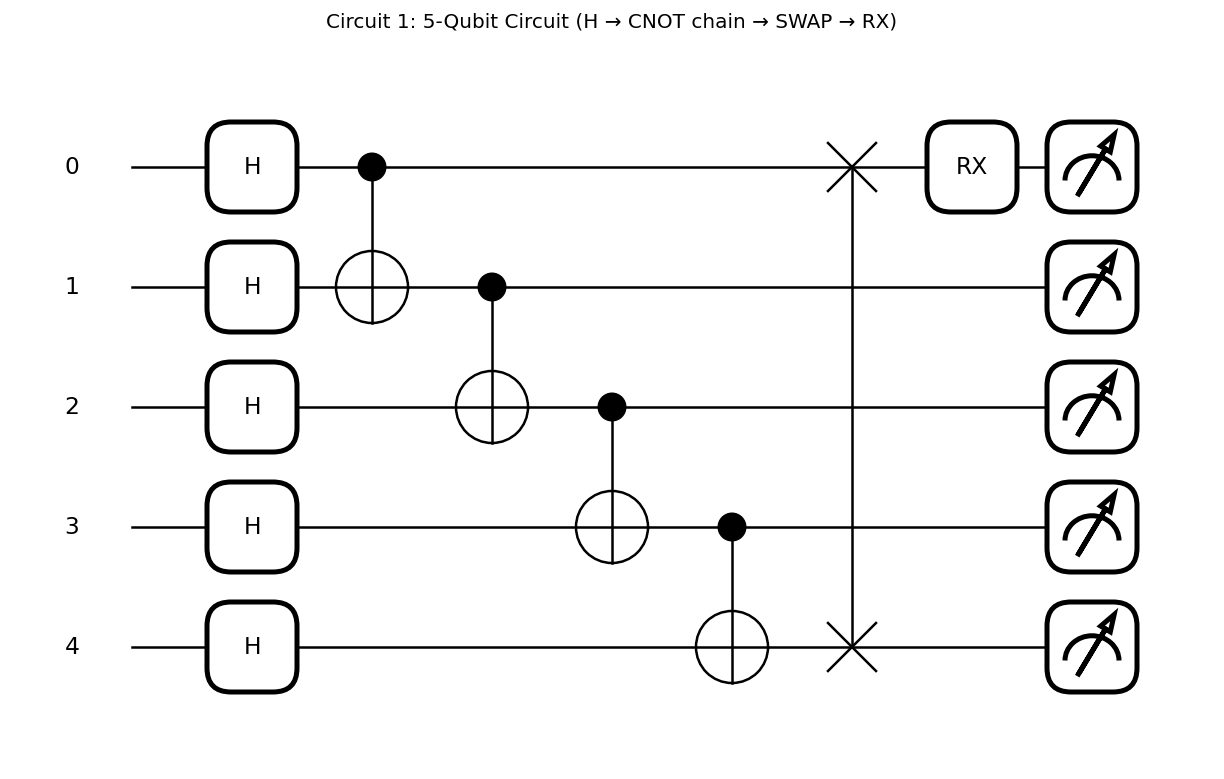

Circuit 1 saved as circuit1.png


In [5]:
# ── Visualize Circuit 1 ──────────────────────────────────────────────────────
fig, ax = qml.draw_mpl(circuit1)()
ax.set_title('Circuit 1: 5-Qubit Circuit (H → CNOT chain → SWAP → RX)', fontsize=12, pad=12)
plt.tight_layout()
plt.savefig('circuit1.png', bbox_inches='tight')
plt.show()
print('Circuit 1 saved as circuit1.png')

In [6]:
# ── Text drawing ─────────────────────────────────────────────────────────────
print(qml.draw(circuit1)())

0: ──H─╭●──────────╭SWAP──RX(1.57)─┤  State
1: ──H─╰X─╭●───────│───────────────┤  State
2: ──H────╰X─╭●────│───────────────┤  State
3: ──H───────╰X─╭●─│───────────────┤  State
4: ──H──────────╰X─╰SWAP───────────┤  State


---
## Circuit 2: Swap Test

The **Swap Test** measures the overlap (fidelity) between two quantum states:

$$P(\text{ancilla}=0) = \frac{1 + |\langle\psi|\phi\rangle|^2}{2}$$

**State preparation:**
- |ψ⟩ on qubits 0,1: H on q0, RX(π/3) on q1
- |φ⟩ on qubits 2,3: H on q2, H on q3

**Swap Test circuit:**
1. H on ancilla (q4)
2. Controlled-SWAP (Fredkin): ancilla controls SWAP(q0,q2) and SWAP(q1,q3)
3. H on ancilla
4. Measure ancilla → P(0) gives fidelity

In [7]:
# ── Device (4 data qubits + 1 ancilla = 5 wires) ─────────────────────────────
# Wires: 0,1 = |ψ⟩   |   2,3 = |φ⟩   |   4 = ancilla
dev2 = qml.device('default.qubit', wires=5)

@qml.qnode(dev2)
def circuit2():
    # ── Prepare |ψ⟩ on qubits 0,1 ──
    qml.Hadamard(wires=0)           # H on q0
    qml.RX(np.pi / 3, wires=1)     # RX(π/3) on q1

    # ── Prepare |φ⟩ on qubits 2,3 ──
    qml.Hadamard(wires=2)           # H on q2
    qml.Hadamard(wires=3)           # H on q3

    # ── Swap Test using ancilla q4 ──
    qml.Hadamard(wires=4)           # H on ancilla

    # Controlled-SWAP (Fredkin): ancilla=4 controls SWAP of (q0,q2) and (q1,q3)
    qml.CSWAP(wires=[4, 0, 2])      # Controlled-SWAP between q0 and q2
    qml.CSWAP(wires=[4, 1, 3])      # Controlled-SWAP between q1 and q3

    qml.Hadamard(wires=4)           # H on ancilla again

    # Measure ancilla (q4)
    return qml.probs(wires=4)

probs = circuit2()
print(f'Ancilla measurement probabilities:')
print(f'  P(ancilla=|0⟩) = {probs[0]:.6f}')
print(f'  P(ancilla=|1⟩) = {probs[1]:.6f}')

# Estimate fidelity: P(0) = (1 + |<ψ|φ>|^2) / 2  →  |<ψ|φ>|^2 = 2*P(0) - 1
fidelity_sq = max(0, 2 * probs[0] - 1)
print(f'\nEstimated |⟨ψ|φ⟩|² = {fidelity_sq:.6f}')
print(f'Estimated |⟨ψ|φ⟩|  = {np.sqrt(fidelity_sq):.6f}')

Ancilla measurement probabilities:
  P(ancilla=|0⟩) = 0.750000
  P(ancilla=|1⟩) = 0.250000

Estimated |⟨ψ|φ⟩|² = 0.500000
Estimated |⟨ψ|φ⟩|  = 0.707107


/tmp/ipython-input-347/2629488943.py:4: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


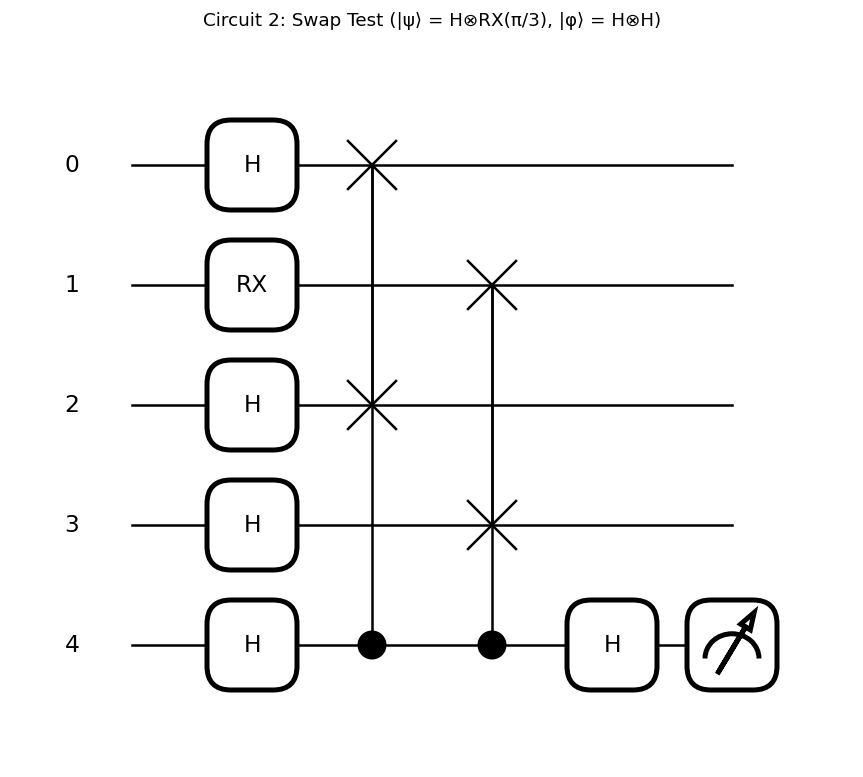

Circuit 2 saved as circuit2.png


In [8]:
# ── Visualize Circuit 2 ──────────────────────────────────────────────────────
fig, ax = qml.draw_mpl(circuit2)()
ax.set_title('Circuit 2: Swap Test (|ψ⟩ = H⊗RX(π/3), |φ⟩ = H⊗H)', fontsize=11, pad=12)
plt.tight_layout()
plt.savefig('circuit2.png', bbox_inches='tight')
plt.show()
print('Circuit 2 saved as circuit2.png')

In [9]:
print(qml.draw(circuit2)())

0: ──H────────╭SWAP──────────┤       
1: ──RX(1.05)─│─────╭SWAP────┤       
2: ──H────────├SWAP─│────────┤       
3: ──H────────│─────├SWAP────┤       
4: ──H────────╰●────╰●─────H─┤  Probs


---
## Verification: Analytical Fidelity Check

We can verify the swap test result analytically. Let's compute the true inner product ⟨ψ|φ⟩ by hand.

In [10]:
# Compute states analytically
# |ψ⟩ = H|0⟩ ⊗ RX(π/3)|0⟩
H_state = np.array([1, 1]) / np.sqrt(2)             # H|0⟩
RX_state = np.array([np.cos(np.pi/6), -1j*np.sin(np.pi/6)])  # RX(π/3)|0⟩
psi = np.kron(H_state, RX_state)

# |φ⟩ = H|0⟩ ⊗ H|0⟩
phi = np.kron(H_state, H_state)

overlap = np.abs(np.dot(psi.conj(), phi))**2
print(f'Analytical |⟨ψ|φ⟩|²  = {overlap:.6f}')
print(f'Swap Test  |⟨ψ|φ⟩|²  = {fidelity_sq:.6f}')
print(f'Match: {np.isclose(overlap, fidelity_sq, atol=1e-5)}')

Analytical |⟨ψ|φ⟩|²  = 0.500000
Swap Test  |⟨ψ|φ⟩|²  = 0.500000
Match: True


---
## Summary

| Circuit | Qubits | Key Gates | Purpose |
|---------|--------|-----------|--------|
| Circuit 1 | 5 | H, CNOT chain, SWAP, RX | Entanglement + rotation demo |
| Circuit 2 | 4 + 1 ancilla | H, RX, CSWAP | Swap Test for state fidelity |

Both circuits are implemented and visualized using **PennyLane** with the `default.qubit` simulator.